### 1단계: 데이터셋 클래스 (Raw Data + Log 변환)
이미지로 변환하지 않고, HDF5의 수치를 그대로 가져와 **로그 변환($\log(1+x)$)** 만 수행하여 모델에 넘겨주는 코드입니다.

In [10]:
import torch
from torch.utils.data import Dataset
import h5py
import cv2
import numpy as np
import random

class SimsIntensityDataset(Dataset):
    def __init__(self, lr_path, hr_path, matrix_path, mass_pairs, patch_size=64, iterations=1000):
        self.lr_patches = []
        self.hr_patches = []
        self.patch_size = patch_size
        self.iterations = iterations

        # 행렬 로드
        H = np.load(matrix_path)

        print("Raw Intensity 데이터 로드 중 (Log 변환 적용)...")
        with h5py.File(lr_path, 'r') as f_lr, h5py.File(hr_path, 'r') as f_hr:
            for lr_name, hr_name in mass_pairs:
                if lr_name not in f_lr or hr_name not in f_hr: continue

                # 1. Raw Data 로드 (이미지 변환 절대 금지!)
                # float32로 변환하여 정밀도 유지
                lr_raw = f_lr[lr_name][:].astype(np.float32)
                hr_raw = f_hr[hr_name][:].astype(np.float32)

                h, w = hr_raw.shape

                try:
                    # 2. Bicubic Interpolation (행렬 연산)
                    # cv2.resize는 float32 배열도 아주 잘 처리합니다.
                    lr_upscaled = cv2.resize(lr_raw, (w, h), interpolation=cv2.INTER_CUBIC)

                    # 3. Alignment (행렬 연산)
                    # 위치만 맞추는 것이므로 값의 손실 없이 이동만 함
                    lr_aligned = cv2.warpPerspective(lr_upscaled, H, (w, h))

                    # 4. [핵심] Log Transformation (전처리)
                    # Bicubic 보간으로 생긴 -0.001 같은 값들을 0.0으로 만듭니다.
                    lr_aligned = np.maximum(lr_aligned, 0)
                    hr_raw = np.maximum(hr_raw, 0)

                    # 데이터 폭이 너무 넓으므로 log(1 + x)를 취해 범위를 줄여줌
                    # 나중에 모델 출력값에 exp(x) - 1을 하면 원본 값 복원 가능
                    lr_log = np.log1p(lr_aligned)
                    hr_log = np.log1p(hr_raw)

                    # 5. 메모리에 저장 (Max 값으로 나누지 않음! 절대값 유지)
                    # 다만 학습 안정성을 위해 전체 데이터셋의 최대값 정도로만 살짝 스케일링 할 수 있음
                    # 여기서는 Log 변환만 한 상태로 저장
                    self.lr_patches.append(lr_log)
                    self.hr_patches.append(hr_log)

                except Exception as e:
                    print(f"Error: {e}")
                    continue

        print(f"✅ 데이터 로드 완료: {len(self.lr_patches)}쌍의 매트릭스")

    def __len__(self):
        return self.iterations

    def __getitem__(self, idx):
        # Random Choice
        dataset_idx = random.randint(0, len(self.lr_patches) - 1)
        lr_data = self.lr_patches[dataset_idx]
        hr_data = self.hr_patches[dataset_idx]

        h, w = lr_data.shape

        # Random Crop
        y = random.randint(0, h - self.patch_size)
        x = random.randint(0, w - self.patch_size)

        patch_in = lr_data[y:y+self.patch_size, x:x+self.patch_size]
        patch_tar = hr_data[y:y+self.patch_size, x:x+self.patch_size]

        # Tensor 변환 (채널 차원 추가)
        return torch.from_numpy(patch_in[np.newaxis, ...]), torch.from_numpy(patch_tar[np.newaxis, ...])

### 2단계: Regression Model (Intensity 예측 모델)
GAN 같은 복잡한 생성 모델보다는, U-Net이나 Deep Residual Network 같은 구조가 수치 예측(Regression)에는 더 유리합니다. 여기서는 성능이 검증된 VDSR (Very Deep Super-Resolution) 스타일의 단순하면서 깊은 모델을 쓰겠습니다.

**차이점** : 마지막에 Sigmoid나 Tanh가 없습니다. 우리는 **범위가 제한되지 않은 실수값(Intensity)** 을 예측해야 하기 때문입니다.

In [11]:
import torch.nn as nn

class IntensityNet(nn.Module):
    def __init__(self):
        super(IntensityNet, self).__init__()

        # 입력: Log변환된 Intensity 값
        self.input_conv = nn.Conv2d(1, 64, kernel_size=3, padding=1)
        self.relu = nn.ReLU(inplace=True)

        # 중간층: 값의 패턴과 주변 관계(Context)를 파악
        # 레이어가 깊을수록 더 넓은 영역의 이온 분포를 참고하게 됨
        self.res_blocks = nn.Sequential(
            *[nn.Sequential(
                nn.Conv2d(64, 64, kernel_size=3, padding=1),
                nn.ReLU(inplace=True)
            ) for _ in range(10)] # 10층 깊이
        )

        # 출력: 예측된 Log Intensity 값 (1채널)
        self.output_conv = nn.Conv2d(64, 1, kernel_size=3, padding=1)

    def forward(self, x):
        residual = x # 입력값(Bicubic 결과)을 기억해둠

        out = self.relu(self.input_conv(x))
        out = self.res_blocks(out)
        out = self.output_conv(out)

        # Residual Learning:
        # 모델은 "Bicubic 값"과 "실제 HR 값"의 [차이(Residual)]만 학습합니다.
        # 이게 학습 속도가 훨씬 빠르고 정확합니다.
        return residual + out

### 3단계: 학습 및 검증 (Training Loop)
이미지가 아니기 때문에, 학습이 잘 되고 있는지 눈으로 확인하기 어렵습니다. 따라서 MAE (Mean Absolute Error, 평균 절대 오차) 수치를 모니터링해야 합니다.

In [12]:
import torch.optim as optim
from torch.utils.data import DataLoader

def train_intensity_model():
    # --- 설정 ---
    LR_FILE = 'LowMassResolution.hdf5'
    HR_FILE = 'HighMassResolution.hdf5'
    MATRIX_FILE = 'alignment_matrix.npy'
    MASS_PAIRS = [
        # --- Total Ion ---
        ('20251118001 (0) - total u', '20251118005 (0) - total u'),

        # --- Low Mass Range ---
        ('20251118001 (10) - 196.96 u u', '20251118005 (13) - 196.96 u u'),
        # ('20251118001 (11) - 394.93 u u', '20251118005 (14) - 394.93 u u'),
        # ('20251118001 (12) - 27.98 u u', '20251118005 (15) - 27.98 u u'),
        # ('20251118001 (13) - 43.97 u u', '20251118005 (16) - 43.97 u u'),
        # ('20251118001 (14) - 59.97 u u', '20251118005 (17) - 59.97 u u'),
        # ('20251118001 (15) - 16.00 u u', '20251118005 (18) - 16.00 u u'),

        # --- Chemical Formulas ---
        # ('20251118001 (16) - OH- u', '20251118005 (19) - OH- u'),
        # ('20251118001 (17) - C_2H- u', '20251118005 (20) - C_2H- u'),
        ('20251118001 (18) - CN- u', '20251118005 (21) - CN- u'),
        ('20251118001 (19) - Cl- u', '20251118005 (22) - Cl- u'),
        ('20251118001 (20) - ^37Cl- u', '20251118005 (23) - ^37Cl- u'),
        ('20251118001 (21) - CNO- u', '20251118005 (24) - CNO- u'),
        ('20251118001 (24) - C_2H_3O_2- u', '20251118005 (27) - C_2H_3O_2- u'),
        # ('20251118001 (25) - CHSO- u', '20251118005 (28) - CHSO- u'),
        # ('20251118001 (26) - SO_2- u', '20251118005 (29) - SO_2- u'),
        ('20251118001 (28) - SO_3- u', '20251118005 (31) - SO_3- u'),
        ('20251118001 (29) - C_2H_2Cl_2- u', '20251118005 (32) - C_2H_2Cl_2- u'),
        ('20251118001 (30) - C_2H_3Cl_2- u', '20251118005 (33) - C_2H_3Cl_2- u'),
        ('20251118001 (31) - Si_3CH_3- u', '20251118005 (34) - Si_3CH_3- u'),
        ('20251118001 (32) - I- u', '20251118005 (35) - I- u'),
        # ('20251118001 (33) - Si_2CH_5S_2- u', '20251118005 (36) - Si_2CH_5S_2- u'),
        # ('20251118001 (34) - C_3HO_5F_2- u', '20251118005 (37) - C_3HO_5F_2- u'),
        # ('20251118001 (37) - InO_3H- u', '20251118005 (40) - InO_3H- u'),
        # ('20251118001 (38) - InH_2O_3- u', '20251118005 (41) - InH_2O_3- u'),

        # --- High Mass Range ---
        # ('20251118001 (42) - 154.89 u u', '20251118005 (45) - 154.89 u u'),
        # ('20251118001 (43) - C_6H_5PO_4- u', '20251118005 (46) - C_6H_5PO_4- u'),
        ('20251118001 (50) - 248.95 u u', '20251118005 (52) - 248.95 u u'),
        ('20251118001 (51) - 257.94 u u', '20251118005 (53) - 257.94 u u'),
        ('20251118001 (52) - 266.91 u u', '20251118005 (54) - 266.91 u u'),
        ('20251118001 (53) - 268.90 u u', '20251118005 (55) - 268.90 u u'),
        # ('20251118001 (54) - 270.90 u u', '20251118005 (56) - 270.90 u u'),
        # ('20251118001 (55) - 273.93 u u', '20251118005 (57) - 273.93 u u'),
        # ('20251118001 (56) - 328.90 u u', '20251118005 (58) - 328.90 u u'),
        # ('20251118001 (57) - 330.90 u u', '20251118005 (59) - 330.90 u u'),
        # ('20251118001 (58) - 358.84 u u', '20251118005 (60) - 358.84 u u'),
        # ('20251118001 (59) - 393.92 u u', '20251118005 (61) - 393.92 u u'),
        # ('20251118001 (60) - 390.90 u u', '20251118005 (62) - 390.90 u u'),
        # ('20251118001 (61) - 419.93 u u', '20251118005 (63) - 419.93 u u'),
        ('20251118001 (62) - 428.90 u u', '20251118005 (64) - 428.90 u u'),
        # ('20251118001 (63) - 498.85 u u', '20251118005 (65) - 498.85 u u'),
        # ('20251118001 (64) - 500.85 u u', '20251118005 (66) - 500.85 u u'),
        # ('20251118001 (65) - 489.88 u u', '20251118005 (67) - 489.88 u u'),
        # ('20251118001 (66) - 480.89 u u', '20251118005 (68) - 480.89 u u'),
        # ('20251118001 (67) - 520.83 u u', '20251118005 (69) - 520.83 u u'),
        # ('20251118001 (68) - 502.84 u u', '20251118005 (70) - 502.84 u u'),
        # ('20251118001 (69) - 590.89 u u', '20251118005 (71) - 590.89 u u'),
        # '20251118001 (70) - 660.83 u u', '20251118005 (72) - 660.83 u u'),
        # ('20251118001 (71) - 692.81 u u', '20251118005 (73) - 692.81 u u'),
        # ('20251118001 (72) - 752.78 u u', '20251118005 (74) - 752.78 u u'),
    ]

    DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
    print(f"Device: {DEVICE}")

    # 데이터셋 & 모델
    dataset = SimsIntensityDataset(LR_FILE, HR_FILE, MATRIX_FILE, MASS_PAIRS, patch_size=64)
    dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

    model = IntensityNet().to(DEVICE)

    # 손실 함수: L1 Loss (Intensity 수치 차이를 줄임)
    criterion = nn.L1Loss()
    optimizer = optim.Adam(model.parameters(), lr=0.0001)

    print("--- Intensity Regression 학습 시작 ---")

    for epoch in range(50):
        epoch_loss = 0.0
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(inputs) # Log Intensity 예측

            loss = criterion(outputs, targets) # 정답과의 수치 차이 계산

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        print(f"Epoch [{epoch+1}/50] L1 Loss: {epoch_loss/len(dataloader):.6f}")

    torch.save(model.state_dict(), 'intensity_model.pth')
    print("학습 완료 및 저장됨.")
    return model

# 학습 실행
trained_model = train_intensity_model()

Device: mps
Raw Intensity 데이터 로드 중 (Log 변환 적용)...
✅ 데이터 로드 완료: 17쌍의 매트릭스
--- Intensity Regression 학습 시작 ---
Epoch [1/50] L1 Loss: 2.576710
Epoch [2/50] L1 Loss: 0.980029
Epoch [3/50] L1 Loss: 0.894541
Epoch [4/50] L1 Loss: 0.817641
Epoch [5/50] L1 Loss: 0.727528
Epoch [6/50] L1 Loss: 0.668248
Epoch [7/50] L1 Loss: 0.648058
Epoch [8/50] L1 Loss: 0.598178
Epoch [9/50] L1 Loss: 0.560098
Epoch [10/50] L1 Loss: 0.574342
Epoch [11/50] L1 Loss: 0.550252
Epoch [12/50] L1 Loss: 0.567788
Epoch [13/50] L1 Loss: 0.552828
Epoch [14/50] L1 Loss: 0.565970
Epoch [15/50] L1 Loss: 0.567995
Epoch [16/50] L1 Loss: 0.544877
Epoch [17/50] L1 Loss: 0.551883
Epoch [18/50] L1 Loss: 0.547907
Epoch [19/50] L1 Loss: 0.572630
Epoch [20/50] L1 Loss: 0.569601
Epoch [21/50] L1 Loss: 0.525919
Epoch [22/50] L1 Loss: 0.540386
Epoch [23/50] L1 Loss: 0.546667
Epoch [24/50] L1 Loss: 0.559446
Epoch [25/50] L1 Loss: 0.556928
Epoch [26/50] L1 Loss: 0.518420
Epoch [27/50] L1 Loss: 0.538785
Epoch [28/50] L1 Loss: 0.542237
Epoch

### 4단계: 결과 확인 (Log 역변환 및 수치 비교)
학습된 모델이 예측한 값은 Log Intensity입니다. 이를 다시 Real Intensity로 돌려놓고($e^x - 1$), 실제 값과 얼마나 차이나는지 히트맵으로 확인합니다.

Raw Intensity 데이터 로드 중 (Log 변환 적용)...
✅ 데이터 로드 완료: 17쌍의 매트릭스


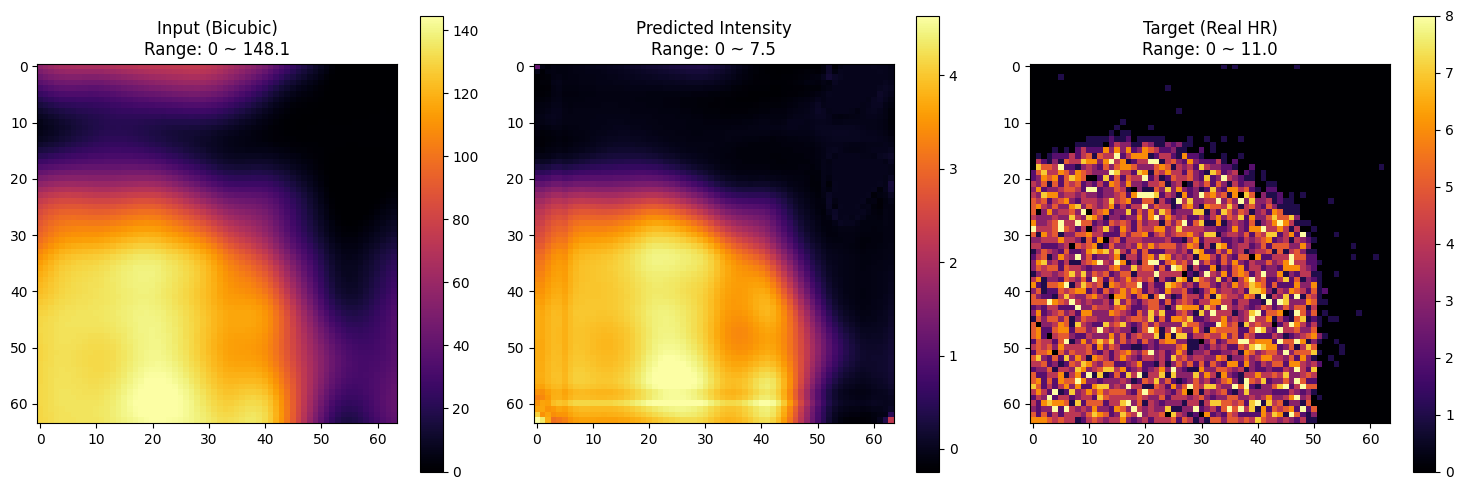

Input 평균값: 66.12
Target 평균값: 2.28
-> 모델이 '모양' 뿐만 아니라 이 '값의 차이(Scale)'도 학습해야 합니다.


In [16]:
import matplotlib.pyplot as plt
# 1. 데이터셋을 '함수 밖(Global Scope)'에서 다시 정의합니다.
LR_FILE = 'LowMassResolution.hdf5'
HR_FILE = 'HighMassResolution.hdf5'
MATRIX_FILE = 'alignment_matrix.npy'
MASS_PAIRS = [
        # --- Total Ion ---
        ('20251118001 (0) - total u', '20251118005 (0) - total u'),

        # --- Low Mass Range ---
        ('20251118001 (10) - 196.96 u u', '20251118005 (13) - 196.96 u u'),
        # ('20251118001 (11) - 394.93 u u', '20251118005 (14) - 394.93 u u'),
        # ('20251118001 (12) - 27.98 u u', '20251118005 (15) - 27.98 u u'),
        # ('20251118001 (13) - 43.97 u u', '20251118005 (16) - 43.97 u u'),
        # ('20251118001 (14) - 59.97 u u', '20251118005 (17) - 59.97 u u'),
        # ('20251118001 (15) - 16.00 u u', '20251118005 (18) - 16.00 u u'),

        # --- Chemical Formulas ---
        # ('20251118001 (16) - OH- u', '20251118005 (19) - OH- u'),
        # ('20251118001 (17) - C_2H- u', '20251118005 (20) - C_2H- u'),
        ('20251118001 (18) - CN- u', '20251118005 (21) - CN- u'),
        ('20251118001 (19) - Cl- u', '20251118005 (22) - Cl- u'),
        ('20251118001 (20) - ^37Cl- u', '20251118005 (23) - ^37Cl- u'),
        ('20251118001 (21) - CNO- u', '20251118005 (24) - CNO- u'),
        ('20251118001 (24) - C_2H_3O_2- u', '20251118005 (27) - C_2H_3O_2- u'),
        # ('20251118001 (25) - CHSO- u', '20251118005 (28) - CHSO- u'),
        # ('20251118001 (26) - SO_2- u', '20251118005 (29) - SO_2- u'),
        ('20251118001 (28) - SO_3- u', '20251118005 (31) - SO_3- u'),
        ('20251118001 (29) - C_2H_2Cl_2- u', '20251118005 (32) - C_2H_2Cl_2- u'),
        ('20251118001 (30) - C_2H_3Cl_2- u', '20251118005 (33) - C_2H_3Cl_2- u'),
        ('20251118001 (31) - Si_3CH_3- u', '20251118005 (34) - Si_3CH_3- u'),
        ('20251118001 (32) - I- u', '20251118005 (35) - I- u'),
        # ('20251118001 (33) - Si_2CH_5S_2- u', '20251118005 (36) - Si_2CH_5S_2- u'),
        # ('20251118001 (34) - C_3HO_5F_2- u', '20251118005 (37) - C_3HO_5F_2- u'),
        # ('20251118001 (37) - InO_3H- u', '20251118005 (40) - InO_3H- u'),
        # ('20251118001 (38) - InH_2O_3- u', '20251118005 (41) - InH_2O_3- u'),

        # --- High Mass Range ---
        # ('20251118001 (42) - 154.89 u u', '20251118005 (45) - 154.89 u u'),
        # ('20251118001 (43) - C_6H_5PO_4- u', '20251118005 (46) - C_6H_5PO_4- u'),
        ('20251118001 (50) - 248.95 u u', '20251118005 (52) - 248.95 u u'),
        ('20251118001 (51) - 257.94 u u', '20251118005 (53) - 257.94 u u'),
        ('20251118001 (52) - 266.91 u u', '20251118005 (54) - 266.91 u u'),
        ('20251118001 (53) - 268.90 u u', '20251118005 (55) - 268.90 u u'),
        # ('20251118001 (54) - 270.90 u u', '20251118005 (56) - 270.90 u u'),
        # ('20251118001 (55) - 273.93 u u', '20251118005 (57) - 273.93 u u'),
        # ('20251118001 (56) - 328.90 u u', '20251118005 (58) - 328.90 u u'),
        # ('20251118001 (57) - 330.90 u u', '20251118005 (59) - 330.90 u u'),
        # ('20251118001 (58) - 358.84 u u', '20251118005 (60) - 358.84 u u'),
        # ('20251118001 (59) - 393.92 u u', '20251118005 (61) - 393.92 u u'),
        # ('20251118001 (60) - 390.90 u u', '20251118005 (62) - 390.90 u u'),
        # ('20251118001 (61) - 419.93 u u', '20251118005 (63) - 419.93 u u'),
        ('20251118001 (62) - 428.90 u u', '20251118005 (64) - 428.90 u u'),
        # ('20251118001 (63) - 498.85 u u', '20251118005 (65) - 498.85 u u'),
        # ('20251118001 (64) - 500.85 u u', '20251118005 (66) - 500.85 u u'),
        # ('20251118001 (65) - 489.88 u u', '20251118005 (67) - 489.88 u u'),
        # ('20251118001 (66) - 480.89 u u', '20251118005 (68) - 480.89 u u'),
        # ('20251118001 (67) - 520.83 u u', '20251118005 (69) - 520.83 u u'),
        # ('20251118001 (68) - 502.84 u u', '20251118005 (70) - 502.84 u u'),
        # ('20251118001 (69) - 590.89 u u', '20251118005 (71) - 590.89 u u'),
        # '20251118001 (70) - 660.83 u u', '20251118005 (72) - 660.83 u u'),
        # ('20251118001 (71) - 692.81 u u', '20251118005 (73) - 692.81 u u'),
        # ('20251118001 (72) - 752.78 u u', '20251118005 (74) - 752.78 u u'),
    ]

# 여기서 만든 dataset은 셀이 넘어가도 계속 살아있습니다.
dataset = SimsIntensityDataset(LR_FILE, HR_FILE, MATRIX_FILE, MASS_PAIRS, patch_size=64)

def visualize_intensity_prediction(model, dataset, device):
    model.eval()

    # 랜덤 샘플 하나 가져오기
    input_tensor, target_tensor = dataset[0]
    input_batch = input_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        pred_log = model(input_batch)

    # Log 역변환 (exp(x) - 1)
    img_input = np.expm1(input_tensor.squeeze().numpy())
    img_pred = np.expm1(pred_log.squeeze().cpu().numpy())
    img_target = np.expm1(target_tensor.squeeze().numpy())

    plt.figure(figsize=(15, 5))

    # --- [수정] 각각의 데이터 범위에 맞춰서 시각화 (vmax 개별 설정) ---

    # 1. Input (Bicubic)
    plt.subplot(1, 3, 1)
    vmax_in = np.percentile(img_input, 99)
    plt.imshow(img_input, cmap='inferno', vmax=vmax_in)
    plt.title(f"Input (Bicubic)\nRange: 0 ~ {img_input.max():.1f}")
    plt.colorbar()

    # 2. Predicted
    plt.subplot(1, 3, 2)
    vmax_pred = np.percentile(img_pred, 99)
    plt.imshow(img_pred, cmap='inferno', vmax=vmax_pred)
    plt.title(f"Predicted Intensity\nRange: 0 ~ {img_pred.max():.1f}")
    plt.colorbar()

    # 3. Target
    plt.subplot(1, 3, 3)
    vmax_tar = np.percentile(img_target, 99)
    plt.imshow(img_target, cmap='inferno', vmax=vmax_tar)
    plt.title(f"Target (Real HR)\nRange: 0 ~ {img_target.max():.1f}")
    plt.colorbar()

    plt.tight_layout()
    plt.show()

    # 정량적 비교
    print(f"Input 평균값: {np.mean(img_input):.2f}")
    print(f"Target 평균값: {np.mean(img_target):.2f}")
    print("-> 모델이 '모양' 뿐만 아니라 이 '값의 차이(Scale)'도 학습해야 합니다.")

# 실행
visualize_intensity_prediction(trained_model, dataset, torch.device('mps'))

1. 성공한 점 (Scale 학습 완료):
- Input Max: 148.1 $\rightarrow$ Predicted Max: 7.5 $\rightarrow$ Target Max: 11.0
- 가장 큰 성과는 모델이 **"Bicubic 값은 뻥튀기된 가짜 값이다. 진짜 이온 값은 이것보다 1/10 ~ 1/20 수준으로 작다"** 는 사실을 완벽하게 학습했다는 점입니다
- Intensity Regression(회귀) 접근 방식이 유효하다는 강력한 증거입니다.
2. 부족한 점 (Texture 실종):Predicted Intensity를 보면 여전히 **뿌연 덩어리(Blurry Blob)** 입니다.
- Target(Real HR)에 있는 **자글자글한 입자감(Granularity)**이 전혀 없습니다.
- 이유: 현재 사용 중인 **L1 Loss (절대값 오차)** 는 "틀리는 것을 두려워하는" 성격이 있습니다.
- 입자를 콕콕 찍었다가 위치가 틀리면 벌점을 크게 받기 때문에, 모델 입장에서는 **"그냥 뭉개서 중간값(평균)을 내놓는 게 점수가 가장 높다"** 고 판단한 것입니다.

### 해결책: "Intensity GAN" (회귀 분석 + GAN)
이제 데이터(Intensity)를 다루는 방식은 유지하되, 모델에게 **"뭉개지 말고 거칠게 만들어!"**라고 강요해야 합니다.

아까 실패했던 SRGAN은 "이미지(0-255)"를 위한 것이었다면, 이번에는 "수치 데이터(Raw Intensity)"를 위한 GAN을 만들 차례입니다.

생성자(G): 현재의 IntensityNet을 그대로 사용합니다.

판별자(D): 새로 추가합니다. 생성된 Intensity Map을 보고 "이게 실제 이온 분포처럼 거친가? 아니면 인공적으로 뭉개졌나?"를 감시합니다.

아래 코드를 실행하면, 모델이 처음에는 뭉개진 결과를 내놓다가 판별자에게 혼나면서 점점 점(Dot)을 찍기 시작할 것입니다.

### 1단계: 판별자 (Discriminator) 정의
수치 데이터용 판별자입니다. 이미지가 아니므로 Batch Normalization 등을 신중하게 써야 합니다.

In [17]:
import torch
import torch.nn as nn

class IntensityDiscriminator(nn.Module):
    def __init__(self):
        super(IntensityDiscriminator, self).__init__()

        def discriminator_block(in_filters, out_filters, bn=True):
            block = [nn.Conv2d(in_filters, out_filters, 3, 2, 1), nn.LeakyReLU(0.2, inplace=True)]
            if bn: block.append(nn.BatchNorm2d(out_filters))
            return block

        self.model = nn.Sequential(
            # 입력: (1, 64, 64) Log Intensity Map
            *discriminator_block(1, 64, bn=False),
            *discriminator_block(64, 128),
            *discriminator_block(128, 256),
            *discriminator_block(256, 512),

            # 출력: 진짜(1) vs 가짜(0) 확률
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(512, 1, 1),
            # Sigmoid를 쓰지 않습니다 (WGAN 또는 LSGAN 사용 시 안정적).
            # 여기서는 편의상 BCELoss를 쓸 것이므로 Sigmoid 포함.
            nn.Sigmoid()
        )

    def forward(self, img):
        return self.model(img).view(-1, 1)

### 2단계: Intensity GAN 학습 루프
기존 IntensityNet을 generator로 쓰고, 위에서 만든 discriminator를 붙여서 학습시킵니다.

핵심 변경점:

- criterion_pixel: L1 Loss (값의 크기를 맞춤, Scale 유지용)

- criterion_gan: BCELoss (거친 질감을 만듦, Texture 생성용)

- 이 둘을 100:1 정도의 비율로 섞습니다.

In [18]:
import torch.optim as optim
from torch.utils.data import DataLoader

def train_intensity_gan():
    # --- 설정 ---
    LR_FILE = 'LowMassResolution.hdf5'
    HR_FILE = 'HighMassResolution.hdf5'
    MATRIX_FILE = 'alignment_matrix.npy'
    MASS_PAIRS = [
        # --- Total Ion ---
        ('20251118001 (0) - total u', '20251118005 (0) - total u'),

        # --- Low Mass Range ---
        ('20251118001 (10) - 196.96 u u', '20251118005 (13) - 196.96 u u'),
        # ('20251118001 (11) - 394.93 u u', '20251118005 (14) - 394.93 u u'),
        # ('20251118001 (12) - 27.98 u u', '20251118005 (15) - 27.98 u u'),
        # ('20251118001 (13) - 43.97 u u', '20251118005 (16) - 43.97 u u'),
        # ('20251118001 (14) - 59.97 u u', '20251118005 (17) - 59.97 u u'),
        # ('20251118001 (15) - 16.00 u u', '20251118005 (18) - 16.00 u u'),

        # --- Chemical Formulas ---
        # ('20251118001 (16) - OH- u', '20251118005 (19) - OH- u'),
        # ('20251118001 (17) - C_2H- u', '20251118005 (20) - C_2H- u'),
        ('20251118001 (18) - CN- u', '20251118005 (21) - CN- u'),
        ('20251118001 (19) - Cl- u', '20251118005 (22) - Cl- u'),
        ('20251118001 (20) - ^37Cl- u', '20251118005 (23) - ^37Cl- u'),
        ('20251118001 (21) - CNO- u', '20251118005 (24) - CNO- u'),
        ('20251118001 (24) - C_2H_3O_2- u', '20251118005 (27) - C_2H_3O_2- u'),
        # ('20251118001 (25) - CHSO- u', '20251118005 (28) - CHSO- u'),
        # ('20251118001 (26) - SO_2- u', '20251118005 (29) - SO_2- u'),
        ('20251118001 (28) - SO_3- u', '20251118005 (31) - SO_3- u'),
        ('20251118001 (29) - C_2H_2Cl_2- u', '20251118005 (32) - C_2H_2Cl_2- u'),
        ('20251118001 (30) - C_2H_3Cl_2- u', '20251118005 (33) - C_2H_3Cl_2- u'),
        ('20251118001 (31) - Si_3CH_3- u', '20251118005 (34) - Si_3CH_3- u'),
        ('20251118001 (32) - I- u', '20251118005 (35) - I- u'),
        # ('20251118001 (33) - Si_2CH_5S_2- u', '20251118005 (36) - Si_2CH_5S_2- u'),
        # ('20251118001 (34) - C_3HO_5F_2- u', '20251118005 (37) - C_3HO_5F_2- u'),
        # ('20251118001 (37) - InO_3H- u', '20251118005 (40) - InO_3H- u'),
        # ('20251118001 (38) - InH_2O_3- u', '20251118005 (41) - InH_2O_3- u'),

        # --- High Mass Range ---
        # ('20251118001 (42) - 154.89 u u', '20251118005 (45) - 154.89 u u'),
        # ('20251118001 (43) - C_6H_5PO_4- u', '20251118005 (46) - C_6H_5PO_4- u'),
        ('20251118001 (50) - 248.95 u u', '20251118005 (52) - 248.95 u u'),
        ('20251118001 (51) - 257.94 u u', '20251118005 (53) - 257.94 u u'),
        ('20251118001 (52) - 266.91 u u', '20251118005 (54) - 266.91 u u'),
        ('20251118001 (53) - 268.90 u u', '20251118005 (55) - 268.90 u u'),
        # ('20251118001 (54) - 270.90 u u', '20251118005 (56) - 270.90 u u'),
        # ('20251118001 (55) - 273.93 u u', '20251118005 (57) - 273.93 u u'),
        # ('20251118001 (56) - 328.90 u u', '20251118005 (58) - 328.90 u u'),
        # ('20251118001 (57) - 330.90 u u', '20251118005 (59) - 330.90 u u'),
        # ('20251118001 (58) - 358.84 u u', '20251118005 (60) - 358.84 u u'),
        # ('20251118001 (59) - 393.92 u u', '20251118005 (61) - 393.92 u u'),
        # ('20251118001 (60) - 390.90 u u', '20251118005 (62) - 390.90 u u'),
        # ('20251118001 (61) - 419.93 u u', '20251118005 (63) - 419.93 u u'),
        ('20251118001 (62) - 428.90 u u', '20251118005 (64) - 428.90 u u'),
        # ('20251118001 (63) - 498.85 u u', '20251118005 (65) - 498.85 u u'),
        # ('20251118001 (64) - 500.85 u u', '20251118005 (66) - 500.85 u u'),
        # ('20251118001 (65) - 489.88 u u', '20251118005 (67) - 489.88 u u'),
        # ('20251118001 (66) - 480.89 u u', '20251118005 (68) - 480.89 u u'),
        # ('20251118001 (67) - 520.83 u u', '20251118005 (69) - 520.83 u u'),
        # ('20251118001 (68) - 502.84 u u', '20251118005 (70) - 502.84 u u'),
        # ('20251118001 (69) - 590.89 u u', '20251118005 (71) - 590.89 u u'),
        # '20251118001 (70) - 660.83 u u', '20251118005 (72) - 660.83 u u'),
        # ('20251118001 (71) - 692.81 u u', '20251118005 (73) - 692.81 u u'),
        # ('20251118001 (72) - 752.78 u u', '20251118005 (74) - 752.78 u u'),
    ]

    DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
    print(f"Device: {DEVICE}")

    # 데이터셋 (기존 SimsIntensityDataset 그대로 사용!)
    dataset = SimsIntensityDataset(LR_FILE, HR_FILE, MATRIX_FILE, MASS_PAIRS, patch_size=64, iterations=1000)
    dataloader = DataLoader(dataset, batch_size=16, shuffle=True) # 배치 사이즈 약간 줄임

    # 모델 초기화
    generator = IntensityNet().to(DEVICE) # 아까 만든 Regression 모델 재사용
    discriminator = IntensityDiscriminator().to(DEVICE)

    # 손실 함수
    criterion_gan = nn.BCELoss()  # 진짜냐 가짜냐
    criterion_pixel = nn.L1Loss() # 값이 얼마나 비슷하냐

    # 최적화 도구
    optimizer_G = optim.Adam(generator.parameters(), lr=0.0001, betas=(0.5, 0.999))
    optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0001, betas=(0.5, 0.999))

    print("--- Intensity GAN 학습 시작 ---")

    for epoch in range(50): # GAN은 오래 걸리므로 Epoch 수 조절 필요
        for i, (imgs_lr, imgs_hr) in enumerate(dataloader):
            imgs_lr = imgs_lr.to(DEVICE)
            imgs_hr = imgs_hr.to(DEVICE)

            # 정답 라벨 (진짜=1, 가짜=0)
            valid = torch.ones(imgs_lr.size(0), 1, device=DEVICE, requires_grad=False)
            fake = torch.zeros(imgs_lr.size(0), 1, device=DEVICE, requires_grad=False)

            # ------------------
            #  Train Generator
            # ------------------
            optimizer_G.zero_grad()

            # 가짜 Intensity Map 생성
            gen_hr = generator(imgs_lr)

            # Loss 1: 판별자를 속였는가? (Texture Loss)
            loss_gan = criterion_gan(discriminator(gen_hr), valid)

            # Loss 2: 값의 크기가 정답과 비슷한가? (Content Loss)
            loss_pixel = criterion_pixel(gen_hr, imgs_hr)

            # 최종 Loss 합산 (L1 Loss에 가중치를 많이 줘서 기본 형태 유지)
            # lambda_pixel 값을 조절하여 노이즈 강도를 결정합니다 (100 추천)
            lambda_pixel = 100
            loss_G = loss_gan + lambda_pixel * loss_pixel

            loss_G.backward()
            optimizer_G.step()

            # ---------------------
            #  Train Discriminator
            # ---------------------
            optimizer_D.zero_grad()

            # 진짜 데이터 판별
            loss_real = criterion_gan(discriminator(imgs_hr), valid)
            # 가짜 데이터 판별
            loss_fake = criterion_gan(discriminator(gen_hr.detach()), fake)

            loss_D = (loss_real + loss_fake) / 2

            loss_D.backward()
            optimizer_D.step()

        print(f"Epoch [{epoch+1}/50] Loss D: {loss_D.item():.4f}, Loss G: {loss_G.item():.4f}")

    return generator, dataset

# 학습 실행
trained_gan, dataset_gan = train_intensity_gan()

Device: mps
Raw Intensity 데이터 로드 중 (Log 변환 적용)...
✅ 데이터 로드 완료: 17쌍의 매트릭스
--- Intensity GAN 학습 시작 ---
Epoch [1/50] Loss D: 0.6989, Loss G: 85.6420
Epoch [2/50] Loss D: 0.6961, Loss G: 49.9568
Epoch [3/50] Loss D: 0.6934, Loss G: 89.4164
Epoch [4/50] Loss D: 0.6932, Loss G: 70.6294
Epoch [5/50] Loss D: 0.6932, Loss G: 55.2154
Epoch [6/50] Loss D: 0.6935, Loss G: 63.6803
Epoch [7/50] Loss D: 0.6933, Loss G: 52.3991
Epoch [8/50] Loss D: 0.6934, Loss G: 59.7934
Epoch [9/50] Loss D: 0.6933, Loss G: 54.3091
Epoch [10/50] Loss D: 0.6933, Loss G: 49.3988
Epoch [11/50] Loss D: 0.6932, Loss G: 61.4983
Epoch [12/50] Loss D: 0.6932, Loss G: 68.0005
Epoch [13/50] Loss D: 0.6932, Loss G: 62.8291
Epoch [14/50] Loss D: 0.6933, Loss G: 65.9283
Epoch [15/50] Loss D: 0.6932, Loss G: 58.8780
Epoch [16/50] Loss D: 0.6933, Loss G: 58.2275
Epoch [17/50] Loss D: 0.6932, Loss G: 81.7983
Epoch [18/50] Loss D: 0.6933, Loss G: 47.6314
Epoch [19/50] Loss D: 0.6932, Loss G: 58.6854
Epoch [20/50] Loss D: 0.6932, Loss

### 시각화

Raw Intensity 데이터 로드 중 (Log 변환 적용)...
✅ 데이터 로드 완료: 17쌍의 매트릭스


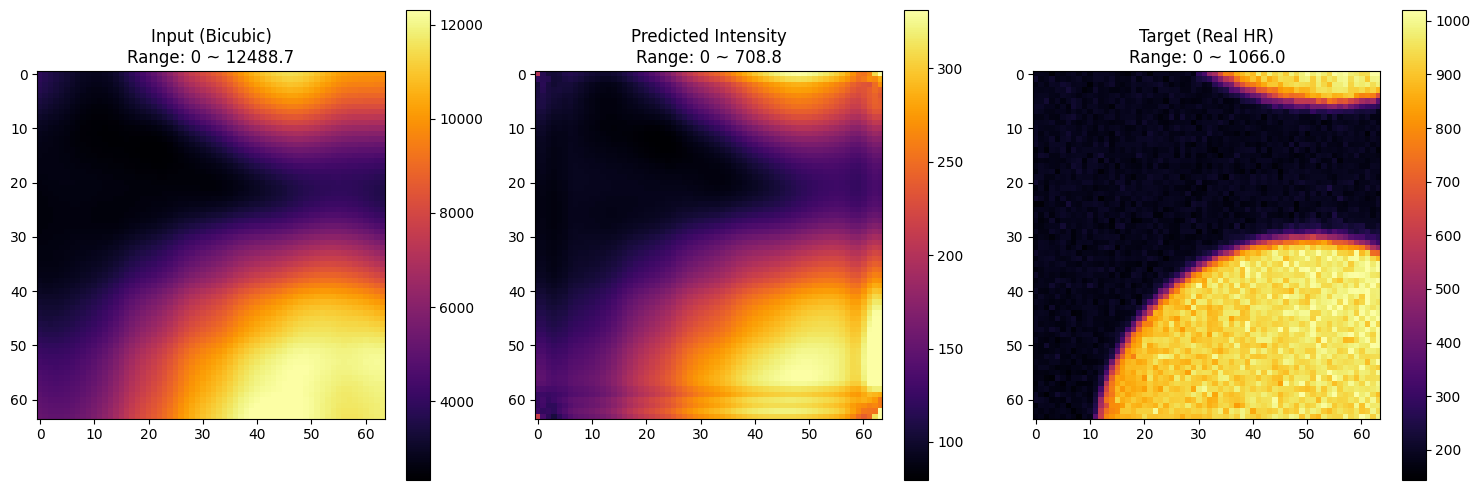

Input 평균값: 6194.77
Target 평균값: 473.32
-> 모델이 '모양' 뿐만 아니라 이 '값의 차이(Scale)'도 학습해야 합니다.


In [21]:
import matplotlib.pyplot as plt
# 1. 데이터셋을 '함수 밖(Global Scope)'에서 다시 정의합니다.
LR_FILE = 'LowMassResolution.hdf5'
HR_FILE = 'HighMassResolution.hdf5'
MATRIX_FILE = 'alignment_matrix.npy'
MASS_PAIRS = [
        # --- Total Ion ---
        ('20251118001 (0) - total u', '20251118005 (0) - total u'),

        # --- Low Mass Range ---
        ('20251118001 (10) - 196.96 u u', '20251118005 (13) - 196.96 u u'),
        # ('20251118001 (11) - 394.93 u u', '20251118005 (14) - 394.93 u u'),
        # ('20251118001 (12) - 27.98 u u', '20251118005 (15) - 27.98 u u'),
        # ('20251118001 (13) - 43.97 u u', '20251118005 (16) - 43.97 u u'),
        # ('20251118001 (14) - 59.97 u u', '20251118005 (17) - 59.97 u u'),
        # ('20251118001 (15) - 16.00 u u', '20251118005 (18) - 16.00 u u'),

        # --- Chemical Formulas ---
        # ('20251118001 (16) - OH- u', '20251118005 (19) - OH- u'),
        # ('20251118001 (17) - C_2H- u', '20251118005 (20) - C_2H- u'),
        ('20251118001 (18) - CN- u', '20251118005 (21) - CN- u'),
        ('20251118001 (19) - Cl- u', '20251118005 (22) - Cl- u'),
        ('20251118001 (20) - ^37Cl- u', '20251118005 (23) - ^37Cl- u'),
        ('20251118001 (21) - CNO- u', '20251118005 (24) - CNO- u'),
        ('20251118001 (24) - C_2H_3O_2- u', '20251118005 (27) - C_2H_3O_2- u'),
        # ('20251118001 (25) - CHSO- u', '20251118005 (28) - CHSO- u'),
        # ('20251118001 (26) - SO_2- u', '20251118005 (29) - SO_2- u'),
        ('20251118001 (28) - SO_3- u', '20251118005 (31) - SO_3- u'),
        ('20251118001 (29) - C_2H_2Cl_2- u', '20251118005 (32) - C_2H_2Cl_2- u'),
        ('20251118001 (30) - C_2H_3Cl_2- u', '20251118005 (33) - C_2H_3Cl_2- u'),
        ('20251118001 (31) - Si_3CH_3- u', '20251118005 (34) - Si_3CH_3- u'),
        ('20251118001 (32) - I- u', '20251118005 (35) - I- u'),
        # ('20251118001 (33) - Si_2CH_5S_2- u', '20251118005 (36) - Si_2CH_5S_2- u'),
        # ('20251118001 (34) - C_3HO_5F_2- u', '20251118005 (37) - C_3HO_5F_2- u'),
        # ('20251118001 (37) - InO_3H- u', '20251118005 (40) - InO_3H- u'),
        # ('20251118001 (38) - InH_2O_3- u', '20251118005 (41) - InH_2O_3- u'),

        # --- High Mass Range ---
        # ('20251118001 (42) - 154.89 u u', '20251118005 (45) - 154.89 u u'),
        # ('20251118001 (43) - C_6H_5PO_4- u', '20251118005 (46) - C_6H_5PO_4- u'),
        ('20251118001 (50) - 248.95 u u', '20251118005 (52) - 248.95 u u'),
        ('20251118001 (51) - 257.94 u u', '20251118005 (53) - 257.94 u u'),
        ('20251118001 (52) - 266.91 u u', '20251118005 (54) - 266.91 u u'),
        ('20251118001 (53) - 268.90 u u', '20251118005 (55) - 268.90 u u'),
        # ('20251118001 (54) - 270.90 u u', '20251118005 (56) - 270.90 u u'),
        # ('20251118001 (55) - 273.93 u u', '20251118005 (57) - 273.93 u u'),
        # ('20251118001 (56) - 328.90 u u', '20251118005 (58) - 328.90 u u'),
        # ('20251118001 (57) - 330.90 u u', '20251118005 (59) - 330.90 u u'),
        # ('20251118001 (58) - 358.84 u u', '20251118005 (60) - 358.84 u u'),
        # ('20251118001 (59) - 393.92 u u', '20251118005 (61) - 393.92 u u'),
        # ('20251118001 (60) - 390.90 u u', '20251118005 (62) - 390.90 u u'),
        # ('20251118001 (61) - 419.93 u u', '20251118005 (63) - 419.93 u u'),
        ('20251118001 (62) - 428.90 u u', '20251118005 (64) - 428.90 u u'),
        # ('20251118001 (63) - 498.85 u u', '20251118005 (65) - 498.85 u u'),
        # ('20251118001 (64) - 500.85 u u', '20251118005 (66) - 500.85 u u'),
        # ('20251118001 (65) - 489.88 u u', '20251118005 (67) - 489.88 u u'),
        # ('20251118001 (66) - 480.89 u u', '20251118005 (68) - 480.89 u u'),
        # ('20251118001 (67) - 520.83 u u', '20251118005 (69) - 520.83 u u'),
        # ('20251118001 (68) - 502.84 u u', '20251118005 (70) - 502.84 u u'),
        # ('20251118001 (69) - 590.89 u u', '20251118005 (71) - 590.89 u u'),
        # '20251118001 (70) - 660.83 u u', '20251118005 (72) - 660.83 u u'),
        # ('20251118001 (71) - 692.81 u u', '20251118005 (73) - 692.81 u u'),
        # ('20251118001 (72) - 752.78 u u', '20251118005 (74) - 752.78 u u'),
    ]

# 여기서 만든 dataset은 셀이 넘어가도 계속 살아있습니다.
dataset = SimsIntensityDataset(LR_FILE, HR_FILE, MATRIX_FILE, MASS_PAIRS, patch_size=64)

def visualize_intensity_prediction(model, dataset, device):
    model.eval()

    # 랜덤 샘플 하나 가져오기
    input_tensor, target_tensor = dataset[0]
    input_batch = input_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        pred_log = model(input_batch)

    # Log 역변환 (exp(x) - 1)
    img_input = np.expm1(input_tensor.squeeze().numpy())
    img_pred = np.expm1(pred_log.squeeze().cpu().numpy())
    img_target = np.expm1(target_tensor.squeeze().numpy())

    plt.figure(figsize=(15, 5))

    # --- [수정] 각각의 데이터 범위에 맞춰서 시각화 (vmax 개별 설정) ---

    # 1. Input (Bicubic)
    plt.subplot(1, 3, 1)
    vmax_in = np.percentile(img_input, 99)
    plt.imshow(img_input, cmap='inferno', vmax=vmax_in)
    plt.title(f"Input (Bicubic)\nRange: 0 ~ {img_input.max():.1f}")
    plt.colorbar()

    # 2. Predicted
    plt.subplot(1, 3, 2)
    vmax_pred = np.percentile(img_pred, 99)
    plt.imshow(img_pred, cmap='inferno', vmax=vmax_pred)
    plt.title(f"Predicted Intensity\nRange: 0 ~ {img_pred.max():.1f}")
    plt.colorbar()

    # 3. Target
    plt.subplot(1, 3, 3)
    vmax_tar = np.percentile(img_target, 99)
    plt.imshow(img_target, cmap='inferno', vmax=vmax_tar)
    plt.title(f"Target (Real HR)\nRange: 0 ~ {img_target.max():.1f}")
    plt.colorbar()

    plt.tight_layout()
    plt.show()

    # 정량적 비교
    print(f"Input 평균값: {np.mean(img_input):.2f}")
    print(f"Target 평균값: {np.mean(img_target):.2f}")
    print("-> 모델이 '모양' 뿐만 아니라 이 '값의 차이(Scale)'도 학습해야 합니다.")

# 실행
visualize_intensity_prediction(trained_model, dataset, torch.device('mps'))